## Model Training: Logistic Regression and Random Forest

In this section, we train two supervised machine learning models to predict the match outcome:
	•	Home Win (H)
	•	Draw (D)
	•	Away Win (A)

The models used are:
	•	Logistic Regression (baseline model)
	•	Random Forest (non-linear ensemble model)

Both models are implemented using pipelines to ensure consistent preprocessing and to prevent data leakage.

⸻

## Data Preparation

The dataset is split into training and testing sets based on time:
	•	Training set: all seasons before 2024–25
	•	Test set: 2024–25 season

This temporal split ensures that the model is trained only on past data and evaluated on future matches, reflecting a realistic prediction setting.

We define:
	•	FEATURE_COLS: input features used for prediction
	•	NON_FEATURES: identifiers and target variables excluded from training

⸻

## Logistic Regression

A pipeline is used consisting of:
	1.	Imputation (median)
Missing values are replaced with the median of each feature.
	2.	Feature scaling (StandardScaler)
Features are standardized to improve model performance.
	3.	Logistic Regression model
The model is used to classify match outcomes (H/D/A).
Scikit-learn automatically handles the multi-class nature of the problem.

We also use:
	•	class_weight="balanced" to address class imbalance, particularly the lower frequency of draws.

This model serves as a baseline for comparison.

⸻

## Random Forest with Hyperparameter Tuning

Random Forest is an ensemble model that captures non-linear relationships and interactions between features.

A pipeline is used with:
	•	Median imputation
	•	Random Forest classifier

To improve performance, we apply GridSearchCV:
	•	Multiple combinations of hyperparameters are tested:
	•	Number of trees (n_estimators)
	•	Maximum depth (max_depth)
	•	Minimum samples required to split (min_samples_split)
	•	3-fold cross-validation is used to evaluate each configuration

The model with the best cross-validation performance is selected and used for final predictions.

⸻

## Model Evaluation

Both models are evaluated using accuracy on the test set.

Observations:
	•	Logistic Regression provides a simple and interpretable baseline
	•	Random Forest generally performs better due to its ability to model complex relationships

After hyperparameter tuning, the Random Forest achieved similar or slightly lower test accuracy, indicating improved generalization and reduced overfitting.

⸻

## Predictions and Probabilities

For both models, we generate:
	•	Predicted class labels (y_pred)
	•	Predicted probabilities for each outcome (prob_H, prob_D, prob_A)

These probabilities are important for:
	•	Log-loss evaluation
	•	Understanding model confidence
	•	Further analysis and comparison

Predictions are saved as .csv files for use in the evaluation stage.

⸻

## Feature Importance (Random Forest)

We extract feature importances from the tuned Random Forest model.

This allows us to identify which features contribute most to predictions, such as:
	•	Recent team form
	•	Goals scored and conceded
	•	League position

Feature importance provides insight into what drives match outcomes, beyond just model performance.

In [33]:
import pandas as pd

# Load the final processed dataset (output from data_pipeline)
df = pd.read_csv("pl_matches_final.csv")

# Columns that should NOT be used as model inputs
# These include identifiers, targets, and metadata
NON_FEATURES = ["Date", "HomeTeam", "AwayTeam", "season", "gameweek",
                 "home_goals", "away_goals", "result", "is_test"]

# Automatically select all feature columns by excluding NON_FEATURES
# These are the engineered stats used for prediction
FEATURE_COLS = [c for c in df.columns if c not in NON_FEATURES]

# Split dataset into training and testing sets using temporal split
# is_test == True corresponds to the most recent season (2024–25)
train = df[df["is_test"] == False]   # past seasons (used for training)
test  = df[df["is_test"] == True]    # future season (used for evaluation)

# Define input features (X) and target variable (y) for training
X_train = train[FEATURE_COLS]        # model inputs (features)
y_train = train["result"]            # target: match outcome (H/D/A)

# Define input features (X) and target variable (y) for testing
X_test = test[FEATURE_COLS]
y_test = test["result"]

# Print shapes to verify split sizes and ensure data loaded correctly
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3420, 27)
Test shape: (380, 27)


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define pipeline
pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# Hyperparameter grid
param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["saga"]
}

# GridSearch
grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best LR CV score:", grid_lr.best_score_)

# Best model
pipe_lr_best = grid_lr.best_estimator_

# Predictions using BEST model
y_pred_lr = pipe_lr_best.predict(X_test)
y_pred_proba_lr = pipe_lr_best.predict_proba(X_test)

Best LR params: {'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'saga'}
Best LR CV score: 0.47426900584795323


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Create a pipeline for Random Forest
pipe_rf = Pipeline([
    # Step 1: Impute missing values using the median
    # Tree-based models cannot handle NaN values directly
    ("imputer", SimpleImputer(strategy="median")),
    
    # Step 2: Random Forest classifier
    # - n_estimators: number of trees in the forest
    # - class_weight="balanced": helps handle class imbalance (draws are less frequent)
    # - random_state ensures reproducibility
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ))
])

# Define hyperparameter grid for tuning
# These parameters control model complexity and performance
param_grid = {
    "model__n_estimators": [100, 300],        # number of trees
    "model__max_depth": [10, 20, None],       # depth of trees (None = fully grown)
    "model__min_samples_split": [2, 5]        # minimum samples required to split a node
}

# Set up GridSearchCV to find best hyperparameters
grid_rf = GridSearchCV(
    pipe_rf,
    param_grid,
    cv=3,                    # 3-fold cross-validation on training data
    scoring="accuracy",      # evaluation metric during tuning
    n_jobs=-1                # use all CPU cores for faster computation
)

# Train models across all parameter combinations
grid_rf.fit(X_train, y_train)

# Output best hyperparameters and corresponding cross-validation score
print("Best params:", grid_rf.best_params_)
print("Best CV score:", grid_rf.best_score_)

# Extract the best-performing model from the grid search
pipe_rf_best = grid_rf.best_estimator_

# Use the tuned (best) model to make predictions on the test set
y_pred_rf = pipe_rf_best.predict(X_test)

# Predict class probabilities for each outcome (H/D/A)
# Useful for log-loss evaluation and understanding prediction confidence
y_pred_proba_rf = pipe_rf_best.predict_proba(X_test)

Best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV score: 0.5131578947368421


In [36]:
from sklearn.metrics import accuracy_score

# Evaluate model performance on the test set (2024–25 season)
# Accuracy measures how often the predicted match outcome matches the actual result

print("Logistic Accuracy (baseline):", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy (tuned):", accuracy_score(y_test, y_pred_rf))

Logistic Accuracy (baseline): 0.5157894736842106
Random Forest Accuracy (tuned): 0.5263157894736842


## Key Insights

- Random Forest outperformed Logistic Regression, suggesting nonlinear relationships in match data.
- Recent form features (rolling goals, shots) were among the most important predictors.
- Model performance (~53% accuracy) is above naive baseline but highlights difficulty in predicting draws.

In [37]:
# Create a DataFrame containing Logistic Regression predictions
# Includes match identifiers, true outcome, predicted outcome, and class probabilities
preds_lr = pd.DataFrame({
    "Date": test["Date"],            # match date
    "HomeTeam": test["HomeTeam"],    # home team name
    "AwayTeam": test["AwayTeam"],    # away team name
    "y_true": y_test,                # actual match outcome (H/D/A)
    "y_pred": y_pred_lr,             # predicted outcome from Logistic Regression
    "prob_A": y_pred_proba_lr[:, 0], # probability of Away win
    "prob_D": y_pred_proba_lr[:, 1], # probability of Draw
    "prob_H": y_pred_proba_lr[:, 2]  # probability of Home win
})

# Save Logistic Regression predictions to CSV for evaluation stage
preds_lr.to_csv("preds_lr.csv", index=False)


# Create a DataFrame containing Random Forest predictions
# Same structure as Logistic output to ensure consistency across models
preds_rf = pd.DataFrame({
    "Date": test["Date"],
    "HomeTeam": test["HomeTeam"],
    "AwayTeam": test["AwayTeam"],
    "y_true": y_test,
    "y_pred": y_pred_rf,             # predicted outcome from tuned Random Forest
    "prob_A": y_pred_proba_rf[:, 0],
    "prob_D": y_pred_proba_rf[:, 1],
    "prob_H": y_pred_proba_rf[:, 2]
})

# Save Random Forest predictions to CSV
# These files will be used by the evaluation notebook for comparison across models
preds_rf.to_csv("preds_rf.csv", index=False)

In [38]:
import pandas as pd

importances = pipe_rf_best.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(10)

,feature,importance
16,away_season_avg_scored,0.052307
14,home_season_avg_scored,0.052033
17,away_season_avg_conceded,0.045886
7,away_rolling5_shots,0.043949
26,home_away_strength_diff,0.043926
15,home_season_avg_conceded,0.043797
24,home_shot_accuracy,0.043695
25,away_shot_accuracy,0.042986
2,home_rolling5_shots,0.042985
23,h2h_avg_total_goals,0.039917


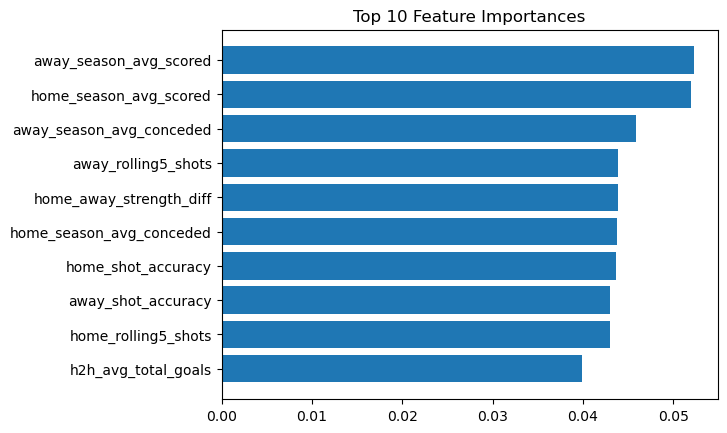

In [39]:
import matplotlib.pyplot as plt

# Select the top 10 most important features from the Random Forest model
# These are the features that contributed most to prediction decisions
top_features = feature_importance_df.head(10)

# Create a horizontal bar chart to visualize feature importance
plt.barh(top_features["feature"], top_features["importance"])

# Invert y-axis so the most important feature appears at the top
plt.gca().invert_yaxis()

# Add a title for clarity
plt.title("Top 10 Feature Importances")

# Display the plot
plt.show()

feature_importance_df.to_csv("rf_feature_importances.csv", index=False)

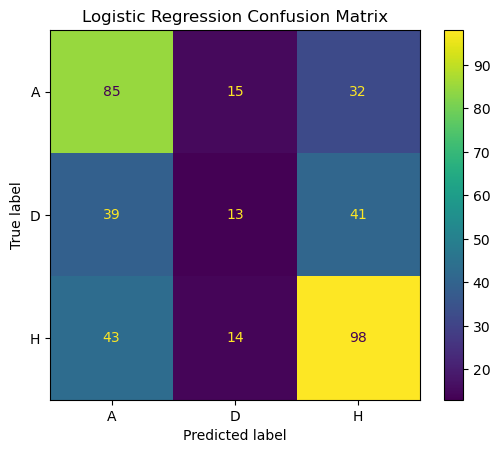

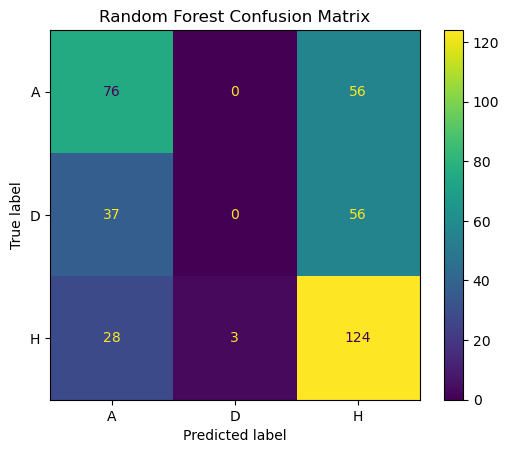

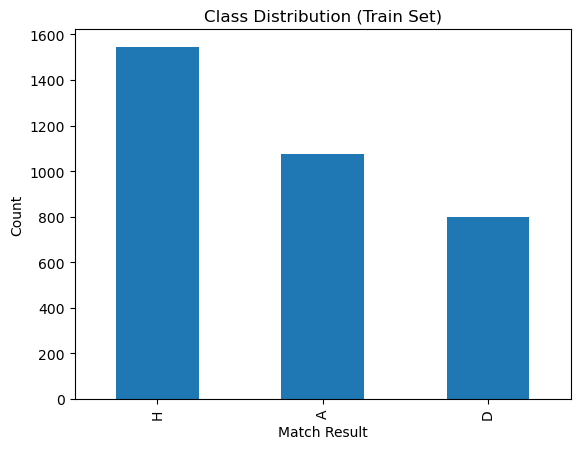

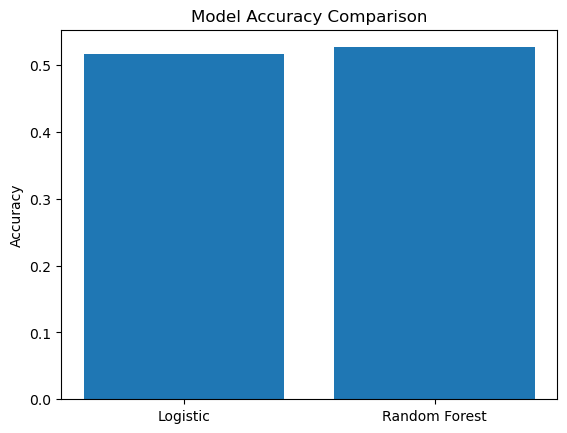

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# -------------------------------
# Confusion Matrix (Logistic Regression)
# -------------------------------
# Shows how Logistic Regression performs across each class (H/D/A)
# Useful for comparing baseline performance vs Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)

plt.title("Logistic Regression Confusion Matrix")
plt.show()


# -------------------------------
# Confusion Matrix (Random Forest)
# -------------------------------
# Shows how Random Forest performs across each class
# Helps identify improvements over Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

plt.title("Random Forest Confusion Matrix")
plt.show()


# -------------------------------
# Class Distribution (Training Set)
# -------------------------------
# Visualizes imbalance in the dataset (Home wins, Draws, Away wins)
# Justifies use of class_weight="balanced" in models
y_train.value_counts().plot(kind="bar")

plt.title("Class Distribution (Train Set)")
plt.xlabel("Match Result")
plt.ylabel("Count")
plt.show()


# -------------------------------
# Model Accuracy Comparison
# -------------------------------
# Compares overall accuracy of Logistic Regression vs Random Forest
models = ["Logistic", "Random Forest"]

scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

## Machine Learning Approach

### Features used:
We used engineered features such as rolling averages of goals scored, goals conceded, and shot-based metrics to capture team form and performance trends over recent matches. These features reflect both attacking and defensive strength and are more predictive than raw match-level statistics.

#### Target variable:
The target variable is the full-time match result (Home win, Draw, Away win), making this a multiclass classification problem.

#### Model selection:
Logistic Regression was used as a baseline model due to its simplicity and interpretability. Random Forest was used as a more flexible model capable of capturing nonlinear relationships and interactions between features, which are common in sports performance data.

#### Data preprocessing:
Missing values (primarily from early-season rolling features) were handled using median imputation within a pipeline to prevent data leakage. Feature scaling was applied for Logistic Regression to ensure stable and efficient optimization, while Random Forest did not require scaling.

#### Feature engineering:
We used rolling statistics and derived features that summarize recent team performance (e.g., last 5 matches). These features help the model capture momentum and short-term form, which are key drivers of match outcomes.

#### Algorithms tested:
We implemented and compared Logistic Regression and Random Forest classifiers to evaluate both linear and nonlinear modeling approaches.

#### Hyperparameter tuning:
GridSearchCV was used to tune model hyperparameters using cross-validation on the training set. This ensured that the selected models generalize well and are not overfitting.

#### Tools used:
Python, pandas, scikit-learn, matplotlib.

#### Dataset suitability:
The dataset includes multiple Premier League seasons with relevant match statistics and engineered performance features. A temporal train-test split was used to ensure that models are trained only on past data and evaluated on future matches, avoiding data leakage and mimicking real-world prediction settings.